# Correction - Evaluation intermédiaire Python pour la data science (S2 2026)

## Exploitation de données électorales avec Python

### Question 1


In [1]:
import pandas as pd

# Données en entrée
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)
df.head()

/tmp/ipykernel_63205/130941828.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


In [3]:
# Nettoyer les données

df["code_departement"] = df["code_departement"].astype(str).str.strip()
df["code_commune"] = df["code_commune"].astype(str).str.strip()

df["prenom"] = df["prenom"].astype(str).str.strip()
df["nom"] = df["nom"].astype(str).str.strip()

In [4]:
# Ne pas concatener si à l'étranger
# Concaténer les 2 premiers chiffres du code_departement
# Avec le code_commune avec zfill 3
def build_insee_code(dep, commune):
    if dep != "fr_etranger":
        return dep[:2] + commune.zfill(3)
    else:
        return commune

In [5]:
df['code_commune'] = df.apply(
    lambda row: build_insee_code(row['code_departement'], row['code_commune']),
    axis=1
)

df["candidat"] = df["prenom"] + " " + df["nom"]

df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


### Question 2

In [6]:
# Lister toutes les valeurs disponibles dans la variable candidats
df["candidat"].unique()

array(['Nathalie ARTHAUD', 'Fabien ROUSSEL', 'Emmanuel MACRON',
       'Jean LASSALLE', 'Marine LE PEN', 'Éric ZEMMOUR',
       'Jean-Luc MÉLENCHON', 'Anne HIDALGO', 'Yannick JADOT',
       'Valérie PÉCRESSE', 'Philippe POUTOU', 'Nicolas DUPONT-AIGNAN',
       'nan abstentions', 'nan blancs', 'nan nuls'], dtype=object)

In [7]:
# Exclure les lignes où candidat commence par "nan"
df_without_nan_voices = df[~df['candidat'].str.startswith('nan')]

# Compter le nombre de valeurs possibles que la variable candidat puisse avoir
candidats = df_without_nan_voices["candidat"].nunique()

f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."


"En 2022, il y avait 12 candidats à l'élection présidentielle."

### Question 3

In [8]:
df_scores = (
    df_without_nan_voices
    .groupby("candidat")
    .agg({"voix": "sum"})
    .sort_values("voix", ascending=False)
    .reset_index()
)

df_scores["Score (% exprimés)"] = df_scores["voix"]/df_without_nan_voices["voix"].sum()*100
df_scores = df_scores.rename(columns={"voix": "Nombre votes (total)"})

df_scores

,candidat,Nombre votes (total),Score (% exprimés)
0,Emmanuel MACRON,9783058,27.845822
1,Marine LE PEN,8133828,23.151568
2,Jean-Luc MÉLENCHON,7712520,21.952386
3,Éric ZEMMOUR,2485226,7.073776
4,Valérie PÉCRESSE,1679001,4.778993
5,Yannick JADOT,1627853,4.633409
6,Jean LASSALLE,1101387,3.134912
7,Fabien ROUSSEL,802422,2.283959
8,Nicolas DUPONT-AIGNAN,725176,2.064091
9,Anne HIDALGO,616478,1.754701


#### Option : great_tables

In [9]:
!pip install great-tables --quiet

In [10]:
from great_tables import GT

gt_table = (
    GT(df_scores)
    .tab_header(
        title="Elections",
        subtitle="Résultats du premier tour (📅 10 avril 2022)"
    )
    .fmt_number(columns="Score (% exprimés)", decimals=2)
    .fmt_number(columns="Nombre votes (total)", decimals=0 , use_seps=True, sep_mark=" ")
)

gt_table

GT(_tbl_data=                 candidat  Nombre votes (total)  Score (% exprimés)
0         Emmanuel MACRON               9783058           27.845822
1           Marine LE PEN               8133828           23.151568
2      Jean-Luc MÉLENCHON               7712520           21.952386
3            Éric ZEMMOUR               2485226            7.073776
4        Valérie PÉCRESSE               1679001            4.778993
5           Yannick JADOT               1627853            4.633409
6           Jean LASSALLE               1101387            3.134912
7          Fabien ROUSSEL                802422            2.283959
8   Nicolas DUPONT-AIGNAN                725176            2.064091
9            Anne HIDALGO                616478            1.754701
10        Philippe POUTOU                268904            0.765390
11       Nathalie ARTHAUD                197094            0.560995, _body=<great_tables._gt_data.Body object at 0x7f6805b20830>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='Score (% exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f6805b20440>, _spanners=Spanners([]), _heading=Heading(title='Elections', subtitle='Résultats du premier tour (📅 10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f6805b20c20>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f6805c45950>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f6805b20d70>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f6805b20ad0>, <great_tables._gt_data.FormatInfo object at 0x7f6805c45e50>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), tabl

### Question 4

In [11]:
# Total de votes par département
score_totaux_dep = (
    df_without_nan_voices
    .groupby(["code_departement"], as_index=False)["voix"]
    .sum()
)
score_totaux_dep = score_totaux_dep.rename(columns={"voix": "total_votes_departemental"})

score_totaux_dep.head()

,code_departement,total_votes_departemental
0,01,333024
1,02,265860
2,03,185955
3,04,96683
4,05,86235


In [12]:
# Total de votes par candidat dans chaque département
score_departements = (
    df_without_nan_voices
    .groupby(["code_departement", "candidat"], as_index=False)["voix"]
    .sum()
)
score_departements = score_departements.rename(columns={"voix": "votes_departemental"})

score_departements.head()

,code_departement,candidat,votes_departemental
0,01,Anne HIDALGO,5644
1,01,Emmanuel MACRON,92206
2,01,Fabien ROUSSEL,5938
3,01,Jean LASSALLE,10876
4,01,Jean-Luc MÉLENCHON,57832


In [13]:
# Ajouter la colonne total par département
score_departements = score_departements.merge(
    score_totaux_dep,
    on="code_departement"
)

score_departements.head()

,code_departement,candidat,votes_departemental,total_votes_departemental
0,01,Anne HIDALGO,5644,333024
1,01,Emmanuel MACRON,92206,333024
2,01,Fabien ROUSSEL,5938,333024
3,01,Jean LASSALLE,10876,333024
4,01,Jean-Luc MÉLENCHON,57832,333024


In [14]:
# Score par département
score_departements["score_departemental"] = score_departements["votes_departemental"]/score_departements["total_votes_departemental"]*100

score_departements = score_departements.sort_values(["code_departement","score_departemental"], ascending=[True,False]).reset_index()
score_departements.head()

,index,code_departement,candidat,votes_departemental,total_votes_departemental,score_departemental
0,1,01,Emmanuel MACRON,92206,333024,27.687494
1,5,01,Marine LE PEN,86755,333024,26.050675
2,4,01,Jean-Luc MÉLENCHON,57832,333024,17.365715
3,11,01,Éric ZEMMOUR,27530,333024,8.266671
4,9,01,Valérie PÉCRESSE,17572,333024,5.276497


In [15]:
# Vérification pour le département 11
score_departements[score_departements["code_departement"] == "11"]

,index,code_departement,candidat,votes_departemental,total_votes_departemental,score_departemental
120,125,11,Marine LE PEN,64027,212426,30.140849
121,121,11,Emmanuel MACRON,43104,212426,20.291301
122,124,11,Jean-Luc MÉLENCHON,42039,212426,19.789950
123,131,11,Éric ZEMMOUR,18434,212426,8.677845
124,123,11,Jean LASSALLE,12382,212426,5.828853
125,129,11,Valérie PÉCRESSE,7350,212426,3.460028
126,130,11,Yannick JADOT,6322,212426,2.976095
127,120,11,Anne HIDALGO,6166,212426,2.902658
128,122,11,Fabien ROUSSEL,5622,212426,2.646569
129,127,11,Nicolas DUPONT-AIGNAN,4206,212426,1.979984


### Question 5

In [16]:
score_departements = score_departements.merge(df_scores, on="candidat")
score_departements = score_departements.rename(columns={"Nombre votes (total)": "votes_national", "Score (% exprimés)": "score_national"})

In [17]:
score_departements.head()

,index,code_departement,candidat,votes_departemental,total_votes_departemental,score_departemental,votes_national,score_national
0,1,01,Emmanuel MACRON,92206,333024,27.687494,9783058,27.845822
1,5,01,Marine LE PEN,86755,333024,26.050675,8133828,23.151568
2,4,01,Jean-Luc MÉLENCHON,57832,333024,17.365715,7712520,21.952386
3,11,01,Éric ZEMMOUR,27530,333024,8.266671,2485226,7.073776
4,9,01,Valérie PÉCRESSE,17572,333024,5.276497,1679001,4.778993


### Question 6

In [18]:
score_departements["surrepresentation"] = (score_departements["score_departemental"] - score_departements["score_national"])/ score_departements["score_national"] *100
score_departements.head()

,index,code_departement,candidat,votes_departemental,total_votes_departemental,score_departemental,votes_national,score_national,surrepresentation
0,1,01,Emmanuel MACRON,92206,333024,27.687494,9783058,27.845822,-0.568589
1,5,01,Marine LE PEN,86755,333024,26.050675,8133828,23.151568,12.522294
2,4,01,Jean-Luc MÉLENCHON,57832,333024,17.365715,7712520,21.952386,-20.893721
3,11,01,Éric ZEMMOUR,27530,333024,8.266671,2485226,7.073776,16.863630
4,9,01,Valérie PÉCRESSE,17572,333024,5.276497,1679001,4.778993,10.410223


### Question 7

In [19]:
import matplotlib.pyplot as plt

def plot_surrepresentation(
    df,
    candidat_full_name,
    var_candidat_full_name="candidat",
    var_surrepresentation="surrepresentation",
    var_code_departement="code_departement"
):
    
    data = df[df[var_candidat_full_name] == candidat_full_name].copy()
    
    data = data.reindex(
        data[var_surrepresentation].abs().sort_values(ascending=False).index
    ).head(5)
    
    data = data.sort_values(var_surrepresentation, ascending=True)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(
        data[var_code_departement],
        data[var_surrepresentation],
        color="blue"
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Surreprésentation")
    ax.set_ylabel("Département")
    ax.set_title(f'Top 5 des surreprésentations de {candidat_full_name.split()[-1]}')
    plt.tight_layout()
    plt.show()

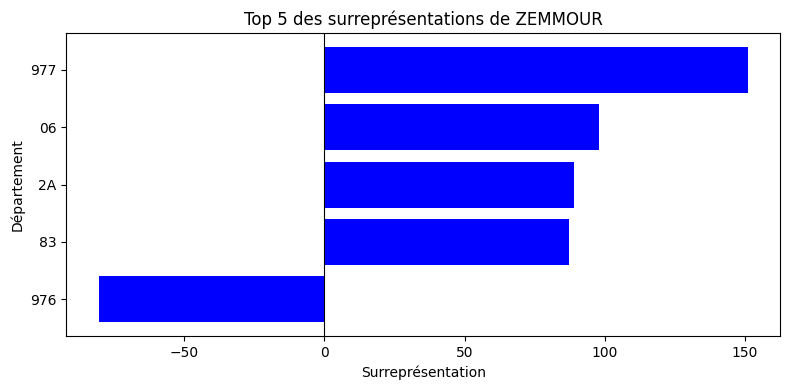

In [20]:
plot_surrepresentation(score_departements, "Éric ZEMMOUR")

### Question 8

In [21]:
!pip install cartiflette --quiet

In [22]:
from cartiflette import carti_download

departement_borders = carti_download(
    values = ["France"],
    crs = 4326,
    borders = "DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
 )

In [23]:
departement_borders.columns

Index(['INSEE_DEP', 'PAYS', 'LIBELLE_DEPARTEMENT', 'POPULATION', 'SOURCE',
       'geometry'],
      dtype='object')

In [24]:
def subset_candidat(
    df,
    candidat_full_name,
    var_candidat_full_name="candidat"
):
    df_subset = df[df[var_candidat_full_name] == candidat_full_name]
    return(df_subset)


In [25]:
def carte_score_dep_candidate(
    score_departements,
    departement_borders,
    candidat_full_name,
    var_candidat_full_name="candidat",
    var_surrepresentation="surrepresentation",
    var_code_departement_score="code_departement",
    var_code_departement_borders="INSEE_DEP",

):
    score_dep_candidat = subset_candidat(score_departements, candidat_full_name)
    carte = departement_borders.merge(score_dep_candidat, left_on=var_code_departement_borders, right_on=var_code_departement_score)
    carte.plot(
        column=var_surrepresentation,
        cmap="bwr",
        legend=True,
        legend_kwds={"label": "% par rapport moyenne nationale"},
        edgecolor="black",
        linewidth=0.5,
    ).set_axis_off()

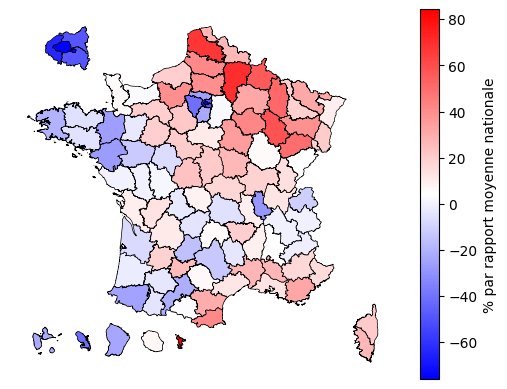

In [26]:
carte_score_dep_candidate(score_departements, departement_borders, "Marine LE PEN")

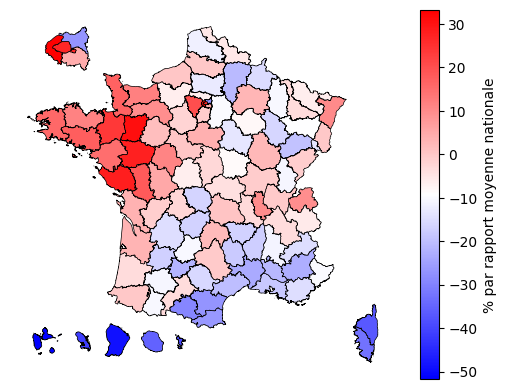

In [27]:
carte_score_dep_candidate(score_departements, departement_borders, "Emmanuel MACRON")

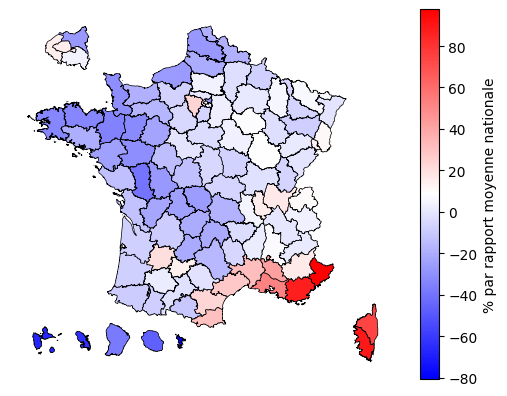

In [28]:
carte_score_dep_candidate(score_departements, departement_borders, "Éric ZEMMOUR")